First run (h=0.01) established as baseline.

--- Run h = 0.06 ---
Total accumulated error: 0.317266079371714
x=0.00, Error=0.0
x=0.06, Error=0.004768632523558747
x=0.12, Error=0.008414380162109603
x=0.18, Error=0.011135566017552834
x=0.24, Error=0.013099374877519221
x=0.30, Error=0.014446437010422364
x=0.36, Error=0.015294764125675153
x=0.42, Error=0.01574312652314125
x=0.48, Error=0.015873948470977173
x=0.55, Error=0.01575578845451603
x=0.61, Error=0.015445461922814152
x=0.67, Error=0.014989856342933872
x=0.73, Error=0.014427481597468261
x=0.79, Error=0.013789792891204244
x=0.85, Error=0.013102318248938122
x=0.91, Error=0.012385618284649236
x=0.97, Error=0.011656102112325928
x=1.03, Error=0.010928263824749374
x=1.09, Error=0.010211653126123765
x=1.15, Error=0.009512353903415274
x=1.21, Error=0.00883621871997603
x=1.27, Error=0.008187482364021198
x=1.33, Error=0.007569061654150701
x=1.39, Error=0.006982807071903754
x=1.45, Error=0.00642971340958335
x=1.52, Error=0.005910095596593702
x=

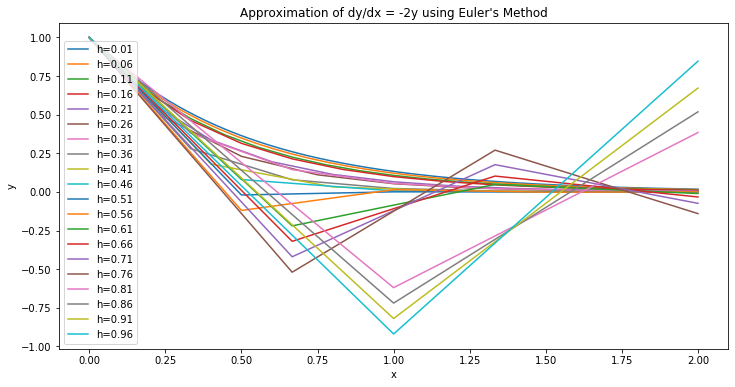

In [4]:
import numpy as np
import matplotlib.pyplot as plt

base_x = None
base_y = None

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

plt.figure(figsize=(12,6))

for h in np.arange(0.01, 1.01, 0.05):
    
    # Define parameters
    x_start, x_end = 0, 2
    num_steps = int(round((x_end - x_start) / h))

    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    if base_x is None:
        base_x = np.copy(x_values)
        base_y = np.copy(y_values)
        print(f"First run (h={h:.2f}) established as baseline.\n")
    else:
        y_base_interp = np.interp(x_values, base_x, base_y)
        errors = np.abs(y_values - y_base_interp)
        total_error = np.sum(errors)
        
        print(f"--- Run h = {h:.2f} ---")
        print(f"Total accumulated error: {total_error}")
        for xv, err in zip(x_values, errors):
            print(f"x={xv:.2f}, Error={err}")
        print("\n")

    # Plot the results
    plt.plot(x_values, y_values, label=f"h={h:.2f}")

plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()